# Análisis Descriptivo y Modelado - Sector Gastronómico Peruano
### Databricks · Spark SQL · **MLlib (PySpark)** · Folium
> **Refactorización Big Data:** Todo el ML corre distribuido con **Spark MLlib**.  
> Se elimina el cuello de botella de `.toPandas()` en los conjuntos de >1.2 M registros.  
> KMeans, TF-IDF y LDA corren sobre el cluster completo sin bajar datos al driver.

**Prerequisito:** Ejecutar primero `Medallon_Final_Corregido.ipynb`.


## 0 · Imports y configuración

In [0]:
# Geo y visualización (estas librerías sí son driver-only - sólo reciben agregados pequeños)
%pip install folium geopandas --quiet


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()


In [0]:
display(spark.sql("SHOW EXTERNAL LOCATIONS"))

name,url,comment
ext-bda-proyecto,abfss://bda-proyecto@sadtvpsemana13.dfs.core.windows.net/,null
ext_ruta,abfss://lab-vivienda@sadtvpsemana13.dfs.core.windows.net/,abfss://lab-vivienda@sadtvpsemana13.dfs.core.windows.net
ws_datab,abfss://unity-catalog-storage@dbstoragerk65c6bisoyc2.dfs.core.windows.net/7405618583204086,null


In [0]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import DoubleType, ArrayType, StringType

from pyspark.ml import Pipeline
from pyspark.ml.feature import (VectorAssembler,StandardScaler,Tokenizer,StopWordsRemover,CountVectorizer,IDF,)
from pyspark.ml.clustering import KMeans, LDA
from pyspark.ml.evaluation import ClusteringEvaluator

# Visualización (driver-only, sobre agregados pequeños)
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
spark = SparkSession.builder.getOrCreate()

CATALOGO= 'proyecto_bda'
SCHEMA= 'bda_schema'
TBL_GOLD_FINAL= f'{CATALOGO}.{SCHEMA}.gold_reviews_final'
TBL_GOLD_STATS_CAT= f'{CATALOGO}.{SCHEMA}.gold_stats_categoria'
TBL_GOLD_FEAT_USUARIO = f'{CATALOGO}.{SCHEMA}.gold_features_usuario'
VOL_GESTIONADO = 'bda_volumen'   # GESTIONADO: GeoJSONs, cache temporal
VOL_MODELOS = 'bda_modelos'   # EXTERNO: modelos ML en Azure ADLS Gen2

# Azure container
STORAGE_ACCOUNT = 'sadtvpsemana13'
CONTAINER = 'bda-proyecto'
RUTA_ABFSS = f'abfss://{CONTAINER}@{STORAGE_ACCOUNT}.dfs.core.windows.net/modelos'

spark.sql(f'CREATE SCHEMA IF NOT EXISTS {CATALOGO}.{SCHEMA}')
# Volumen GESTIONADO
spark.sql(f'CREATE VOLUME IF NOT EXISTS {CATALOGO}.{SCHEMA}.{VOL_GESTIONADO}')

#Revisar conexion
try:
    spark.sql(f"""
        CREATE EXTERNAL VOLUME IF NOT EXISTS {CATALOGO}.{SCHEMA}.{VOL_MODELOS}
        LOCATION '{RUTA_ABFSS}'
    """)
    print('Volumen externo (Azure) listo: ', RUTA_ABFSS)
except Exception as e:
    print('Volumen externo ya existe o error:', str(e)[:300])

VOLUMEN_BASE   = f'/Volumes/{CATALOGO}/{SCHEMA}/{VOL_GESTIONADO}'
VOLUMEN_MODELOS = f'/Volumes/{CATALOGO}/{SCHEMA}/{VOL_MODELOS}'

GEOJSON_DEP = f'{VOLUMEN_BASE}/peru_departamental_simple.geojson'
GEOJSON_PROV = f'{VOLUMEN_BASE}/peru_provincial_simple.geojson'
GEOJSON_DIST = f'{VOLUMEN_BASE}/peru_distrital_simple.geojson'

spark.sql(f'USE CATALOG {CATALOGO}')
spark.sql(f'USE SCHEMA {SCHEMA}')
print("OK")


Volumen externo (Azure) listo:  abfss://bda-proyecto@sadtvpsemana13.dfs.core.windows.net/modelos
OK


## 1)Carga de datos desde la capa Gold

In [0]:
df = spark.table(TBL_GOLD_FINAL)
df.createOrReplaceTempView('gold')

print(f'Registros en Gold : {df.count():,}')
print(f'Columnas: {df.columns}')
df.printSchema()


Registros en Gold : 2,764,295
Columnas: ['place_id', 'id_review', 'caption', 'relative_date', 'review_date', 'retrieval_date', 'rating', 'username', 'n_review_user', 'n_photo_user', 'url_user', 'url_source', 'text_len', 'word_count', 'caption_clean', 'rating_category', 'year', 'month', 'day_of_week', 'name', 'category', 'address', 'phoneNumber', 'coor', 'avg_rating', 'url', 'url_place', 'latitude', 'longitude', 'sentimiento']
root
 |-- place_id: string (nullable = true)
 |-- id_review: string (nullable = true)
 |-- caption: string (nullable = true)
 |-- relative_date: string (nullable = true)
 |-- review_date: timestamp (nullable = true)
 |-- retrieval_date: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- username: string (nullable = true)
 |-- n_review_user: string (nullable = true)
 |-- n_photo_user: string (nullable = true)
 |-- url_user: string (nullable = true)
 |-- url_source: string (nullable = true)
 |-- text_len: integer (nullable = true)
 |-- word_count: i

## 2)Análisis de Engagement Temporal

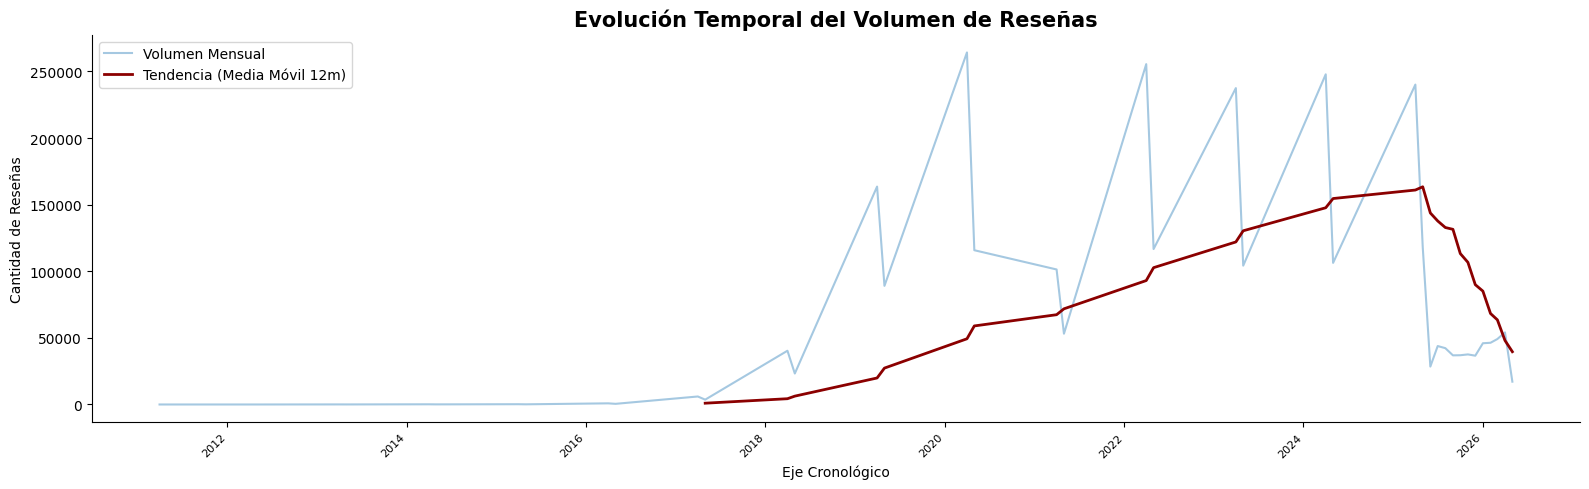

In [0]:
# Volumen mensual (solo se usa pandas para mostrar)
temporal = spark.sql("""
    SELECT
        DATE_FORMAT(review_date, 'yyyy-MM') AS anio_mes,
        COUNT(*) AS total_reviews
    FROM gold
    WHERE review_date IS NOT NULL
    GROUP BY anio_mes
    ORDER BY anio_mes
""").toPandas()

temporal['year_month_dt'] = pd.to_datetime(temporal['anio_mes'])
temporal['rolling_avg']   = temporal['total_reviews'].rolling(window=12).mean()

plt.figure(figsize=(16, 5))
sns.lineplot(data=temporal, x='year_month_dt', y='total_reviews', alpha=0.4, label='Volumen Mensual')
sns.lineplot(data=temporal, x='year_month_dt', y='rolling_avg',color='darkred', linewidth=2, label='Tendencia (Media Móvil 12m)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Evolución Temporal del Volumen de Reseñas', fontsize=15, fontweight='bold')
plt.xlabel('Eje Cronológico'); plt.ylabel('Cantidad de Reseñas')
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

/home/spark-ae12b035-e237-42f8-9110-0f/.ipykernel/78635/command-4742251165243831-3894624048:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=day_dist, x='dia', y='total', palette='Blues_d')


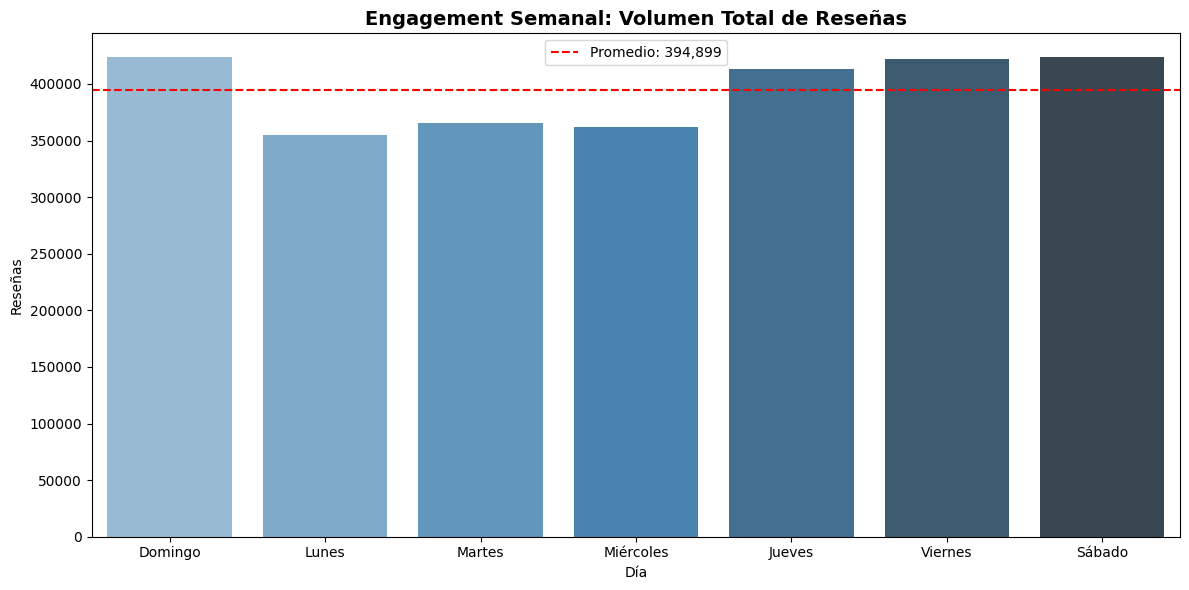

In [0]:
# Distribución por día de la semana
day_map = {1:'Domingo', 2:'Lunes', 3:'Martes', 4:'Miércoles', 5:'Jueves', 6:'Viernes', 7:'Sábado'}

day_dist = spark.sql("""
    SELECT day_of_week, COUNT(*) AS total
    FROM gold
    GROUP BY day_of_week
    ORDER BY day_of_week
""").toPandas()
day_dist['dia'] = day_dist['day_of_week'].map(day_map)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=day_dist, x='dia', y='total', palette='Blues_d')
if ax.get_legend(): ax.get_legend().remove()
plt.axhline(day_dist['total'].mean(), color='red', linestyle='--',label=f'Promedio: {int(day_dist["total"].mean()):,}')
plt.title('Engagement Semanal: Volumen Total de Reseñas', fontsize=14, fontweight='bold')
plt.xlabel('Día'); plt.ylabel('Reseñas'); plt.legend(); plt.tight_layout(); plt.show()

## 3)Análisis Geográfico Regional
Spark SQL agrega coordenadas. Se generan mapas con GeoPandas (departamento, provincia, Lima distrital).


In [0]:
# Agregación via spark solo se usa pandas para vista
geo_agg = spark.sql("""
    SELECT
        place_id, name, category, latitude, longitude,
        COUNT(id_review) AS total_reviews,
        ROUND(AVG(rating), 2) AS avg_rating
    FROM gold
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
    GROUP BY place_id, name, category, latitude, longitude
""").toPandas()

print(f'Locales con coordenadas: {len(geo_agg):,}')


Locales con coordenadas: 38,977


In [0]:
# GeoDataFrame - el join geo se hace en el driver sólo sobre el agregado de locales (gpd.sjoin es una operación de GeoPandas que no existe en Spark)
df_geo = spark.sql("""
    SELECT
        place_id,
        latitude,
        longitude,
        COUNT(*)              AS total_reviews,
        ROUND(AVG(rating), 2) AS avg_rating,
        ROUND(AVG(word_count), 2) AS avg_word_count
    FROM gold
    WHERE latitude IS NOT NULL AND longitude IS NOT NULL
    GROUP BY place_id, latitude, longitude
""").toPandas()

try:
    peru_dep  = gpd.read_file(GEOJSON_DEP)
    peru_prov = gpd.read_file(GEOJSON_PROV)
    peru_dist = gpd.read_file(GEOJSON_DIST)

    gdf_reviews = gpd.GeoDataFrame(df_geo,geometry=gpd.points_from_xy(df_geo.longitude, df_geo.latitude),crs='EPSG:4326') #sobre unicos
    gdf_dep = gpd.sjoin(gdf_reviews, peru_dep[['NOMBDEP', 'geometry']], predicate='within')
    print(f'GeoDataFrame listo: {len(gdf_dep):,} reseñas geolocalizadas')
except FileNotFoundError as e:
    print(f'GeoJSON no encontrado en el volumen: {e}')

GeoDataFrame listo: 37,740 reseñas geolocalizadas


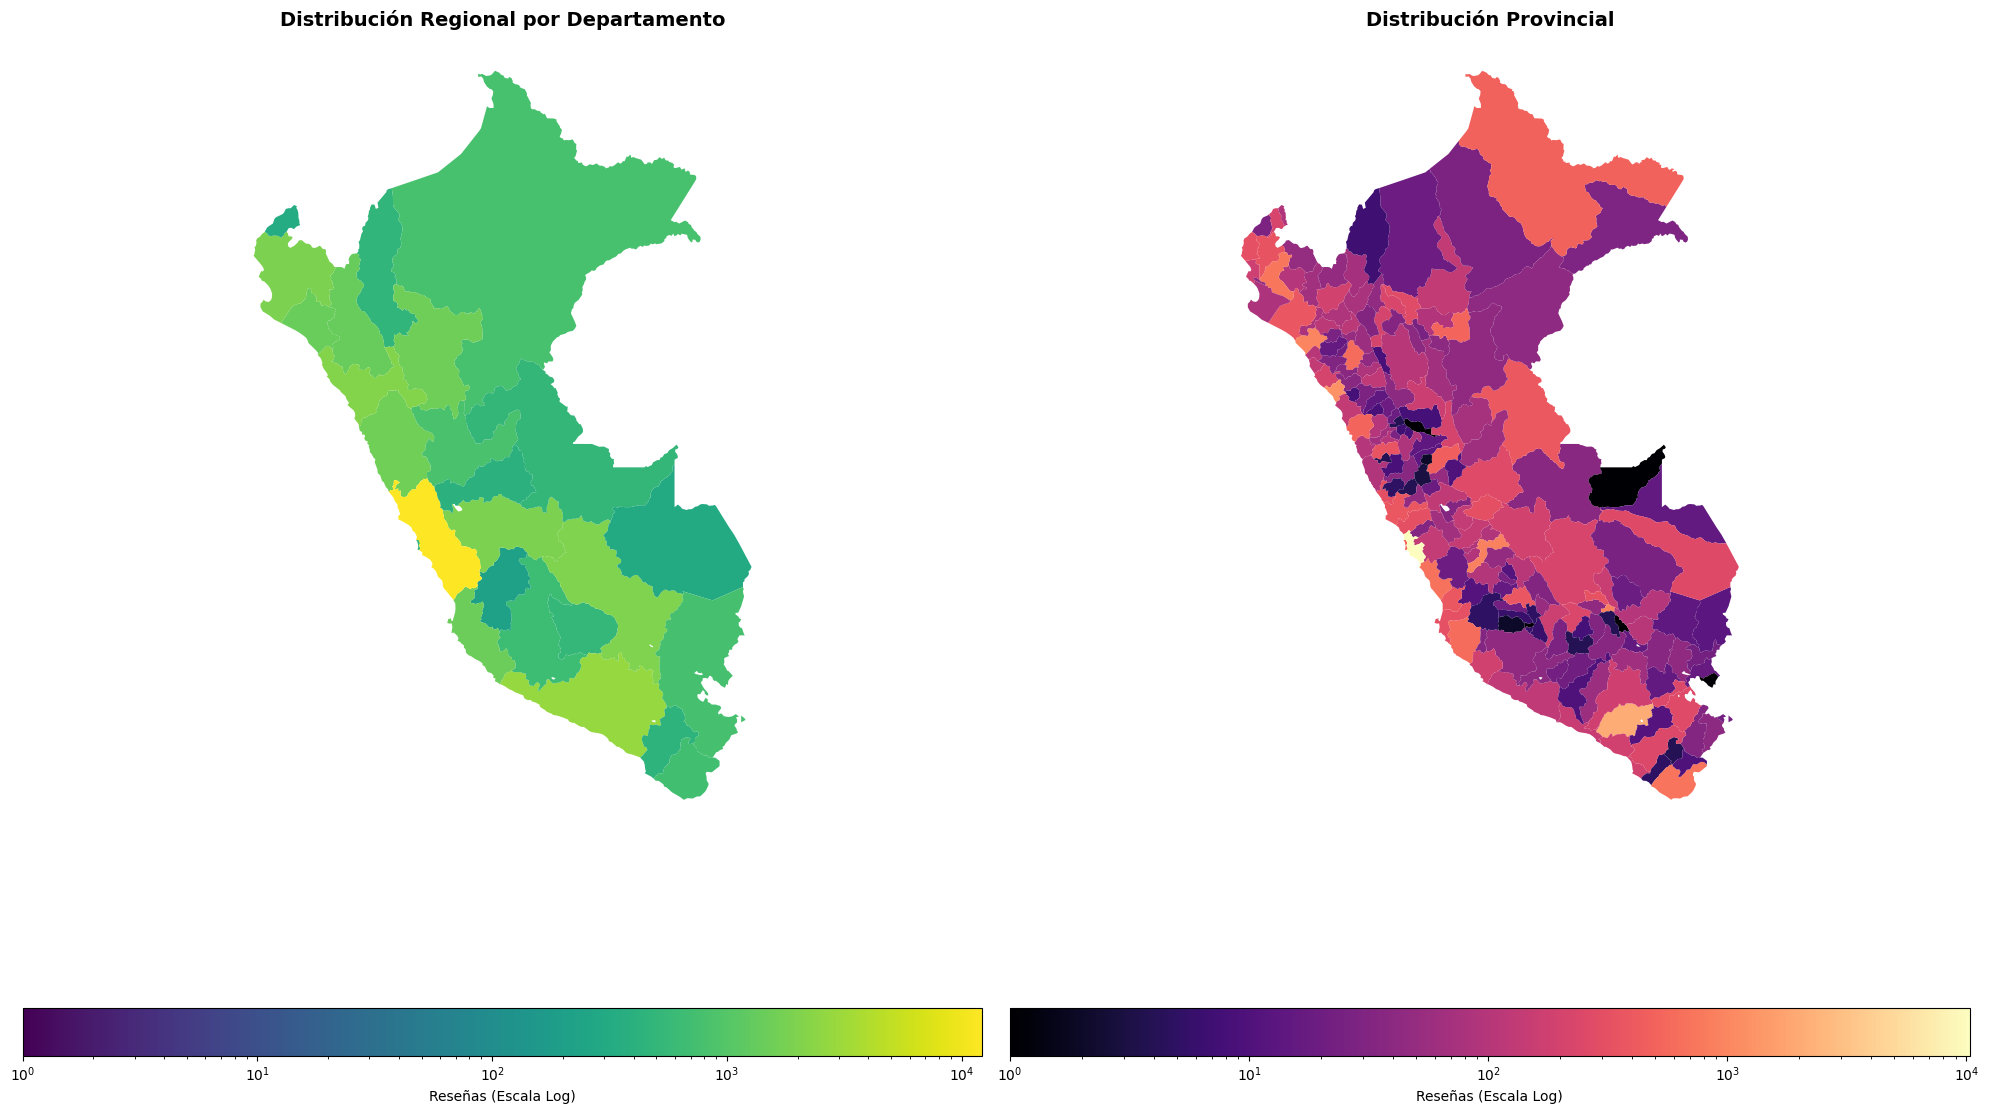

In [0]:
# Mapas coropléticos - Departamento y Provincia
try:
    dep_counts = gdf_dep.groupby('NOMBDEP').size().reset_index(name='review_count')
    dep_map    = peru_dep.merge(dep_counts, on='NOMBDEP', how='left').fillna({'review_count': 1})

    gdf_prov    = gpd.sjoin(gdf_reviews, peru_prov[['NOMBPROV', 'geometry']], predicate='within')
    prov_counts = gdf_prov.groupby('NOMBPROV').size().reset_index(name='review_count')
    prov_map    = peru_prov.merge(prov_counts, on='NOMBPROV', how='left').fillna({'review_count': 1})

    fig, ax = plt.subplots(1, 2, figsize=(20, 12))

    dep_map.plot(column='review_count', ax=ax[0], legend=True, cmap='viridis',
                 norm=colors.LogNorm(vmin=1, vmax=dep_map['review_count'].max()),
                 legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[0].set_title('Distribución Regional por Departamento', fontsize=14, fontweight='bold')
    ax[0].axis('off')

    prov_map.plot(column='review_count', ax=ax[1], legend=True, cmap='magma',
                  norm=colors.LogNorm(vmin=1, vmax=prov_map['review_count'].max()),
                  legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
    ax[1].set_title('Distribución Provincial', fontsize=14, fontweight='bold')
    ax[1].axis('off')

    plt.tight_layout(); plt.show()
except NameError:
    print('Falta carga de GeoDataFrame')

## 4 · Análisis por Categoría de Restaurante

In [0]:
display(spark.table(TBL_GOLD_STATS_CAT).orderBy(F.desc('total_resenas')).limit(9))


category,total_resenas,rating_promedio,rating_desviacion,resenas_positivas,resenas_negativas,promedio_palabras,total_locales,porcentaje_aprobacion
Restaurante,1411515,4.12,1.21,1086549,158855,7.7,17499,76.98
Restaurante peruano,201184,4.25,1.15,162727,19452,9.7,1629,80.88
Pizzería,161541,4.24,1.15,130243,15353,8.0,2095,80.63
Restaurante chino,108663,3.98,1.25,79141,14507,7.2,1020,72.83
Cafetería,102155,4.31,1.1,84625,8560,9.9,1424,82.84
Restaurante de comida rápida,98920,4.09,1.25,75279,12331,7.0,2132,76.1
Restaurante especializado en pollo,96613,4.03,1.27,72018,12719,7.2,1316,74.54
Panadería,78398,4.22,1.12,62441,6861,6.9,2303,79.65
Heladería,67227,4.37,1.06,56710,4985,8.1,1852,84.36


/home/spark-ae12b035-e237-42f8-9110-0f/.ipykernel/78635/command-4742251165243838-2186603008:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.barplot(data=stats_pd, y='category', x='rating_promedio', palette='RdYlGn', ax=axes[0])
/home/spark-ae12b035-e237-42f8-9110-0f/.ipykernel/78635/command-4742251165243838-2186603008:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=stats_pd, y='category', x='porcentaje_aprobacion', palette='Blues_d', ax=axes[1])


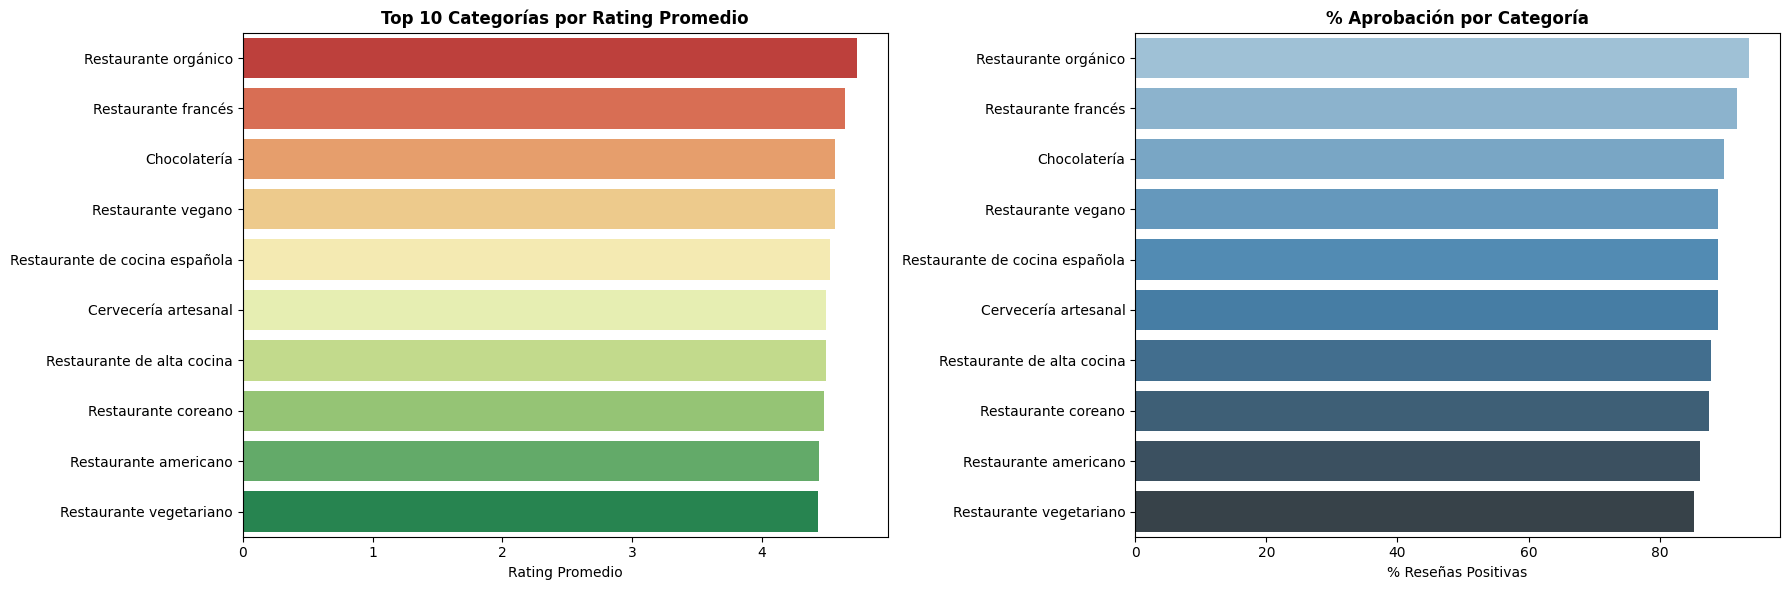

In [0]:
stats_pd = (
    spark.table(TBL_GOLD_STATS_CAT)
    .filter(F.col('total_resenas') > 500)
    .orderBy(F.desc('rating_promedio'))
    .limit(10)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax0 = sns.barplot(data=stats_pd, y='category', x='rating_promedio', palette='RdYlGn', ax=axes[0])
if ax0.get_legend(): ax0.get_legend().remove()
axes[0].set_title('Top 10 Categorías por Rating Promedio', fontweight='bold')
axes[0].set_xlabel('Rating Promedio'); axes[0].set_ylabel('')

ax1 = sns.barplot(data=stats_pd, y='category', x='porcentaje_aprobacion', palette='Blues_d', ax=axes[1])
if ax1.get_legend(): ax1.get_legend().remove()
axes[1].set_title('% Aprobación por Categoría', fontweight='bold')
axes[1].set_xlabel('% Reseñas Positivas'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()


## 5)Segmentación de Usuarios - KMeans con Spark MLlib
Refactorización: `StandardScaler` + `KMeans` + `ClusteringEvaluator` de MLlib.  

In [0]:
# Cargar features desde Gold (permanece como Spark DataFrame)
usuarios = spark.table(TBL_GOLD_FEAT_USUARIO).fillna(0)
print(f'Usuarios para clustering: {usuarios.count():,}')
usuarios.printSchema()

Usuarios para clustering: 1,200,365
root
 |-- username: string (nullable = true)
 |-- review_count: long (nullable = false)
 |-- avg_rating: double (nullable = false)
 |-- std_rating: double (nullable = false)
 |-- avg_word_count: double (nullable = false)
 |-- log_review_count: double (nullable = false)
 |-- log_avg_word_count: double (nullable = false)



In [0]:
# Definición del Pipeline de preprocesamiento
FEATURE_COLS = ['log_review_count', 'avg_rating', 'std_rating', 'log_avg_word_count']

assembler = VectorAssembler(inputCols=FEATURE_COLS,outputCol='features_raw',handleInvalid='skip')
scaler = StandardScaler(inputCol='features_raw',outputCol='features',withMean=True,withStd=True)

# Pipeline de preprocesamiento (sin KMeans todavía — lo añadimos en el loop)
prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model= prep_pipeline.fit(usuarios)
# No tengo persist así que guardo en "cache"(tabla delta)
RUTA_CACHE_SCALED = f'{VOLUMEN_BASE}/_cache_feat_scaled'

prep_model.transform(usuarios).write.format('delta').mode('overwrite').save(RUTA_CACHE_SCALED)

df_escalado = spark.read.format('delta').load(RUTA_CACHE_SCALED)
print(f'Features escaladas: {df_escalado.count():,} filas listas')

Features escaladas: 1,200,365 filas listas


In [0]:
# Búsqueda del K óptimo por Silhouette
import gc
evaluator   = ClusteringEvaluator(featuresCol='features', predictionCol='cluster', metricName='silhouette')
sil_scores  = {}
inertia_log = {}

print(f'  k | silhouette | inercia (WSSSE)')
print(f'----+------------+----------------')

for k in range(2, 10):   # k = 2..9 (consistente con el rango reportado en el informe)
    pipeline_k = Pipeline(stages=[
        VectorAssembler(inputCols=FEATURE_COLS, outputCol='features_raw', handleInvalid='skip'),
        StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True),
        KMeans(featuresCol='features', predictionCol='cluster', k=k, seed=42, maxIter=20)
    ])

    mdl = pipeline_k.fit(usuarios)
    prd = mdl.transform(usuarios)

    sil            = evaluator.evaluate(prd)
    inercia        = mdl.stages[-1].summary.trainingCost
    sil_scores[k]  = round(sil, 4)
    inertia_log[k] = round(inercia, 2)

    print(f'  {k} |   {sil:.4f}   | {inercia:,.0f}')

    del prd, mdl, pipeline_k
    gc.collect()

k_optimo = max(sil_scores, key=sil_scores.get)
print(f'\nK óptimo: {k_optimo}  (silhouette = {sil_scores[k_optimo]})')

  k | silhouette | inercia (WSSSE)
----+------------+----------------
  2 |   0.6185   | 3,270,330
  3 |   0.5747   | 2,905,630
  4 |   0.4732   | 2,118,097
  5 |   0.6105   | 1,394,047
  6 |   0.6116   | 1,212,364
  7 |   0.6308   | 998,682
  8 |   0.6200   | 927,703
  9 |   0.5449   | 927,460

K óptimo: 7  (silhouette = 0.6308)


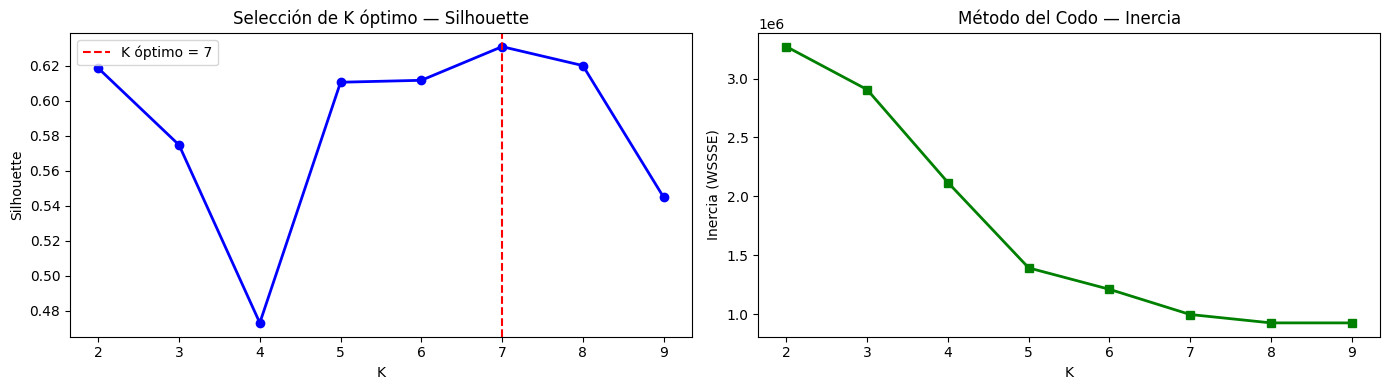

In [0]:
# Curva de silhouette y codo (inercia)
ks = list(sil_scores.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks, [sil_scores[k] for k in ks], 'bo-', linewidth=2)
axes[0].axvline(k_optimo, color='red', linestyle='--', label=f'K óptimo = {k_optimo}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Silhouette')
axes[0].set_title('Selección de K óptimo — Silhouette'); axes[0].legend()

axes[1].plot(ks, [inertia_log[k] for k in ks], 'gs-', linewidth=2)
axes[1].set_xlabel('K'); axes[1].set_ylabel('Inercia (WSSSE)')
axes[1].set_title('Método del Codo — Inercia')

plt.tight_layout(); plt.show()

In [0]:
import gc
del df_escalado
gc.collect()
# Pipeline final con K óptimo
km_final = KMeans(featuresCol='features', predictionCol='cluster', k=k_optimo, seed=42, maxIter=20)

pipeline_kmeans = Pipeline(stages=[assembler, scaler, km_final])
modelo_kmeans   = pipeline_kmeans.fit(usuarios)
sdf_clustered   = modelo_kmeans.transform(usuarios)

sil_final   = evaluator.evaluate(sdf_clustered)
inercia_fin = modelo_kmeans.stages[-1].summary.trainingCost
print(f'Silueta final (k={k_optimo}): {sil_final:.4f} / Inercia: {inercia_fin:,.0f}')

Silueta final (k=7): 0.6308 / Inercia: 998,682


In [0]:
# Perfil de clusters (agregación en Spark, sólo k filas pasan al driver)
resumen_df = (
    sdf_clustered
    .groupBy('cluster')
    .agg(
        F.count('*').alias('n_usuarios'),
        F.round(F.avg('review_count'),2).alias('resenas_promedio'),
        F.round(F.avg('avg_rating'),2).alias('rating_promedio'),
        F.round(F.avg('std_rating'),2).alias('variabilidad_rating'),
        F.round(F.avg('avg_word_count'),2).alias('palabras_promedio'),
    )
    .orderBy('cluster')
)
display(resumen_df)
resumen_pd= resumen_df.toPandas()

cluster,n_usuarios,resenas_promedio,rating_promedio,variabilidad_rating,palabras_promedio
0,75761,3.16,3.26,1.94,11.83
1,464197,1.16,4.79,0.0,1.34
2,69775,1.11,1.5,0.02,30.0
3,272429,1.25,4.87,0.02,17.14
4,65823,14.21,4.14,0.87,9.47
5,109003,1.09,2.16,0.02,1.49
6,143377,3.6,4.32,0.62,3.43


/home/spark-ae12b035-e237-42f8-9110-0f/.ipykernel/78635/command-4742251165243846-1016429243:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_pd, x='cluster', y='count', palette='Spectral', ax=axes[0])


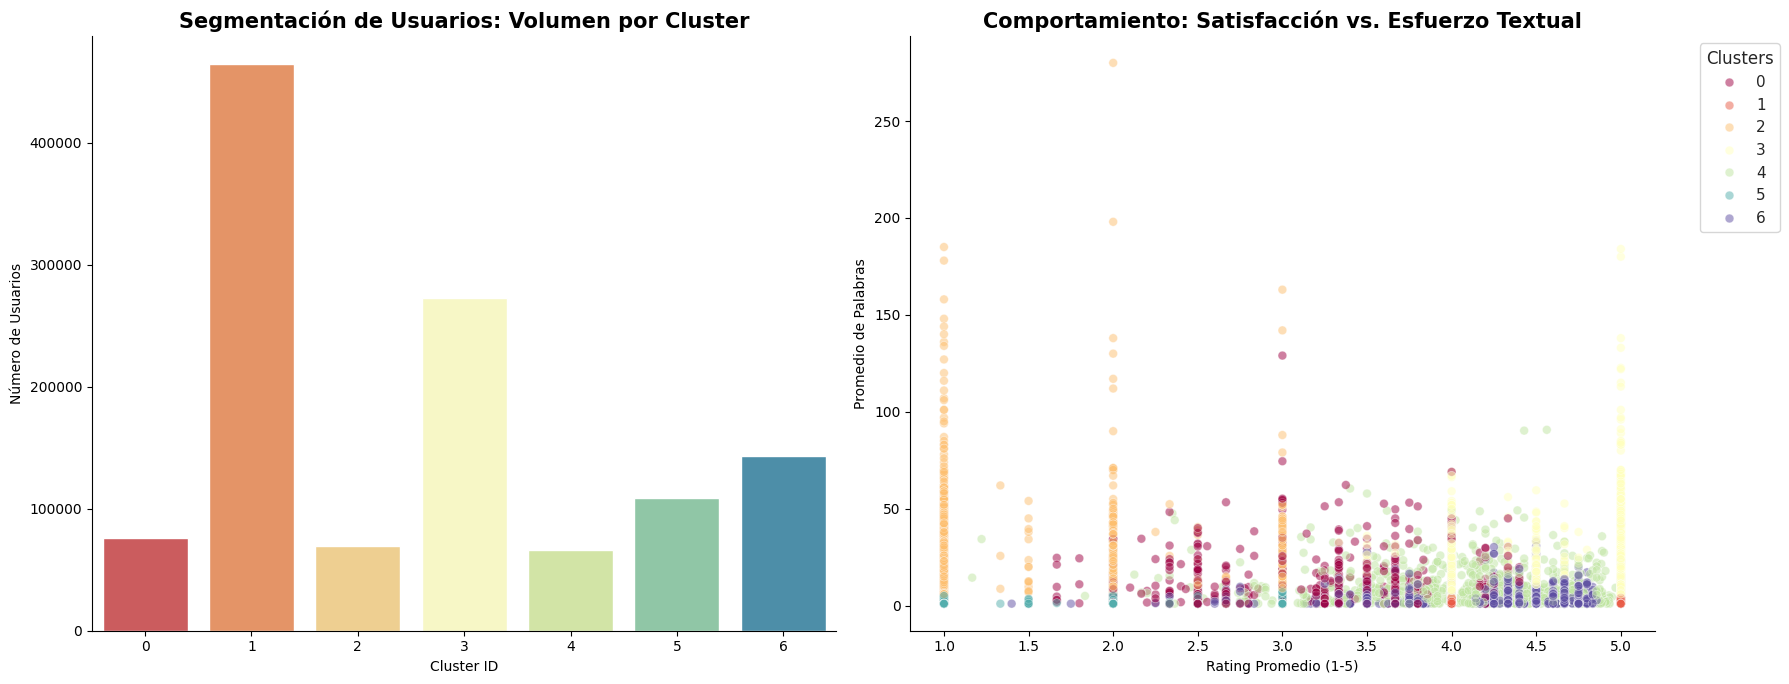

In [0]:
# Visualización: conteo por cluster + scatter sobre muestra pequeña
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style='whitegrid', palette='muted')

# Conteo (agrupado en Spark, sólo k filas al driver)
conteo_pd = sdf_clustered.groupBy('cluster').count().orderBy('cluster').toPandas()
sns.barplot(data=conteo_pd, x='cluster', y='count', palette='Spectral', ax=axes[0])
axes[0].set_title('Segmentación de Usuarios: Volumen por Cluster', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Cluster ID'); axes[0].set_ylabel('Número de Usuarios')

# Scatter - muestra de 15 000 filas para la visualización
scatter_pd = (
    sdf_clustered.select('avg_rating', 'avg_word_count', 'cluster').sample(fraction=min(15_000 / sdf_clustered.count(), 1.0), seed=42)
    .toPandas())
sns.scatterplot(data=scatter_pd, x='avg_rating', y='avg_word_count',hue='cluster', palette='Spectral', alpha=0.5, ax=axes[1], s=40,edgecolor='w')
axes[1].set_title('Comportamiento: Satisfacción vs. Esfuerzo Textual', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Rating Promedio (1-5)'); axes[1].set_ylabel('Promedio de Palabras')
axes[1].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(); plt.tight_layout(); plt.show()

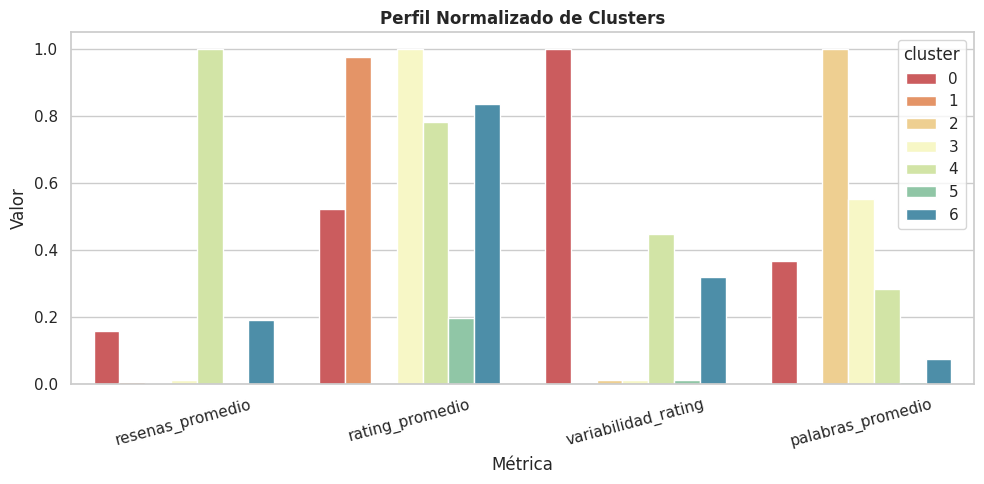

In [0]:
# Perfil normalizado de clusters
metrics = ['resenas_promedio', 'rating_promedio', 'variabilidad_rating', 'palabras_promedio']
resumen_norm = resumen_pd[metrics].copy()
resumen_norm = (resumen_norm - resumen_norm.min()) / (resumen_norm.max() - resumen_norm.min() + 1e-9)
resumen_norm['cluster'] = resumen_pd['cluster'].astype(str)
resumen_melt = resumen_norm.melt(id_vars='cluster', var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resumen_melt, x='Métrica', y='Valor', hue='cluster', palette='Spectral', ax=ax)
ax.set_title('Perfil Normalizado de Clusters', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


<cell_type>markdown</cell_type>### Resultados del Clustering

> **K óptimo seleccionado: 7** · Silhouette: **0.6308** · Inercia (WSSSE): **998 682**
> Se evaluó k = 2..9 sobre 1.2 M usuarios; k = 7 obtuvo el mayor coeficiente de
> silueta. Valores cercanos en k = 2 (0.6185), k = 6 (0.6116) y k = 8 (0.6200)
> sugieren cierta estructura jerárquica en los datos.

> ⚠️ **Nota:** los tamaños (`n_usuarios`) y métricas promedio por clúster se leen
> de la tabla `resumen_pd` (celda anterior). **No se hardcodean** aquí porque las
> etiquetas de clúster que asigna KMeans no son estables entre ejecuciones: el
> "cluster 0" de un run no corresponde necesariamente al "cluster 0" de otro. Tras
> re-ejecutar, mapear cada ID al perfil cualitativo según sus métricas.

### Interpretación de Clusters (perfiles cualitativos)

Los perfiles se asignan leyendo las métricas de `resumen_pd` (rating promedio,
reseñas promedio, variabilidad y palabras promedio). Perfiles típicos esperados:

| Perfil | Señal característica | Acción recomendada |
|--------|----------------------|--------------------|
| Decepcionado silencioso | Una sola visita, rating muy bajo, texto mínimo | Campaña de recuperación: descuento en segunda visita, encuesta de causa |
| Recurrente satisfecho | Rating bueno, engagement moderado | Mantener experiencia — candidato a programa de puntos |
| Validador masivo | Rating casi perfecto pero texto mínimo y sin variabilidad | Verificar autenticidad; si es orgánico, explotar como NPS positivo |
| Crítico detallista | Rating muy bajo, textos largos — escribe para quejarse | Prioridad operacional: escalar quejas a gestión |
| Foodie activo | Usuario más frecuente, rating equilibrado, alta variabilidad | Programa de embajadores / influencer gastronómico |
| Promotor genuino | Rating casi perfecto, textos elaborados | Incentivar reseñas en Google Maps y redes |
| Experiencia errática | Rating medio con altísima variabilidad | Investigar consistencia del servicio en los locales que frecuenta |

> La interpretación es exploratoria y debe validarse antes de automatizar decisiones.

In [0]:
import gc
RUTA_MODELO_KMEANS = f'{VOLUMEN_MODELOS}/modelo_kmeans_usuarios'
print('Guardando KMeans...')
modelo_kmeans.write().overwrite().save(RUTA_MODELO_KMEANS)
print(f'OK → {RUTA_MODELO_KMEANS}')

del sdf_clustered, modelo_kmeans, pipeline_kmeans, km_final
gc.collect()
print('Cache liberado — listo para pipeline NLP')

Guardando KMeans...
OK → /Volumes/proyecto_bda/bda_schema/bda_modelos/modelo_kmeans_usuarios
Cache liberado — listo para pipeline NLP
